# Exp 3 — Imbalanced Dataset Handling

The shortage class is rare (~12.7% of hours). Exp 2 showed that a Decision Tree misses
many true shortages (low recall). This experiment compares six strategies for handling
class imbalance, all using LightGBM as the base classifier.

**Strategies evaluated:**
1. No resampling — LightGBM default (baseline)
2. `class_weight='balanced'` — cost-sensitive learning
3. SMOTE — synthetic minority oversampling in feature space
4. RandomOverSampler — random duplication of minority rows
5. RandomUnderSampler — random removal of majority rows
6. SMOTETomek — SMOTE + Tomek link cleanup (combined)

**Model:** LightGBM (fixes the DT ceiling seen in Exp 2)
**Features:** 17-feature set selected in Exp 2
**Primary metric:** F1 (shortage class) — balances precision vs recall for ops decisions

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# =========================================================
# 1. LOAD DATA
# =========================================================

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
#  Priority 1: real LTA data  →  data/processed/training.parquet
#              Build with: python scripts/build_training_data.py
#  Priority 2: 90-day synthetic fallback (reproducible, seed=42)
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from backend.preprocessing.pipeline import _SG_HOLIDAY_DATES, _SG_SCHOOL_HOLIDAY_RANGES

TRAINING_PARQUET = Path("../data/processed/training.parquet")

if TRAINING_PARQUET.exists():
    df = pd.read_parquet(TRAINING_PARQUET)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = True
    shortage_rate = df["supply_shortage"].dropna().mean()
    print(f"Real LTA data: {len(df):,} rows | shortage rate: {shortage_rate:.2%} | "
          f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
else:
    from backend.ingestion.loader import generate_synthetic_data
    df = generate_synthetic_data(start="2024-01-01", days=90, seed=42)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = False
    print("Synthetic data (run `python scripts/build_training_data.py` to use real LTA data)")

# ── Target: supply drops >40% in next hour? ───────────────────────────────────
if "supply_shortage" not in df.columns:
    df["taxi_count_next"] = df.groupby("zone_id")["taxi_count"].shift(-1)
    df["supply_shortage"] = (df["taxi_count_next"] < df["taxi_count"] * 0.6).astype("Int64")
    df = df.dropna(subset=["supply_shortage"]).copy()
    df["supply_shortage"] = df["supply_shortage"].astype(int)

# ── Base time features (skip if already present from parquet) ─────────────────
if "hour_of_day" not in df.columns:
    df["hour_of_day"]  = df["timestamp"].dt.hour
    df["day_of_week"]  = df["timestamp"].dt.dayofweek
    df["month"]        = df["timestamp"].dt.month
    df["is_weekend"]   = (df["day_of_week"] >= 5)
    df["is_peak_hour"] = df["hour_of_day"].isin(set(range(7,10)) | set(range(17,21)))

# ── Calendar flags ─────────────────────────────────────────────────────────────
ts = df["timestamp"]
tomorrow_strs = (ts + pd.Timedelta(days=1)).dt.strftime("%Y-%m-%d")
df["is_eve_holiday"] = tomorrow_strs.isin(_SG_HOLIDAY_DATES).astype(bool)

if "is_school_holiday" not in df.columns:
    is_school_hol = pd.Series(False, index=df.index)
    for s, e in _SG_SCHOOL_HOLIDAY_RANGES:
        is_school_hol |= (ts >= pd.Timestamp(s, tz="Asia/Singapore")) & \
                         (ts < pd.Timestamp(e, tz="Asia/Singapore") + pd.Timedelta(days=1))
    df["is_school_holiday"] = is_school_hol.astype(bool)

print(f"Loaded {len(df):,} rows across {df['zone_id'].nunique()} zones")
print(f"Shortage rate: {df['supply_shortage'].mean():.2%}  "
      f"({df['supply_shortage'].sum():,} shortage hours / {len(df):,} total)")

# =========================================================
# 2. QUICK SUMMARY — Prior Experiments
# =========================================================

In [3]:
PRIOR = {
    'Exp1 DT (9 feat)':  {'auc': 0.8274, 'f1': 0.4128, 'precision': 0.4880, 'recall': 0.3576},
    'Exp2 DT (17 feat)': {'auc': 0.7669, 'f1': 0.3551, 'precision': 0.2909, 'recall': 0.4556},
}

print('Prior experiments (Decision Tree):')
print(f'{"":<22}  {"AUC":>8}  {"F1":>8}  {"Prec":>8}  {"Recall":>8}')
print('-' * 60)
for name, m in PRIOR.items():
    print(f'{name:<22}  {m["auc"]:>8.4f}  {m["f1"]:>8.4f}  {m["precision"]:>8.4f}  {m["recall"]:>8.4f}')

print()
print('Exp 3 goals (LightGBM + imbalance handling):')
print('  AUC  > 0.88')
print('  F1   > 0.50  (shortage class)')
print('  Recall > 0.55  (catch most real shortages)')

Prior experiments (Decision Tree):
                             AUC        F1      Prec    Recall
------------------------------------------------------------
Exp1 DT (9 feat)          0.8274    0.4128    0.4880    0.3576
Exp2 DT (17 feat)         0.7669    0.3551    0.2909    0.4556

Exp 3 goals (LightGBM + imbalance handling):
  AUC  > 0.88
  F1   > 0.50  (shortage class)
  Recall > 0.55  (catch most real shortages)


# =========================================================
# 3. IMBALANCE ANALYSIS
# =========================================================

In [4]:
# ── Class distribution ────────────────────────────────────────────────────────
counts   = df['supply_shortage'].value_counts()
majority = counts[0]
minority = counts[1]
ratio    = majority / minority

print(f'Class 0 (no shortage): {majority:>7,}  ({majority/len(df):.1%})')
print(f'Class 1 (shortage):    {minority:>7,}  ({minority/len(df):.1%})')
print(f'Imbalance ratio:       {ratio:.1f}:1')
print()
print('Imbalance context: at 7.9:1, the model can achieve 87% accuracy by always'
      ' predicting no shortage — making accuracy a useless metric here.')
print('We will track F1, Recall and Precision-Recall AUC instead.')

Class 0 (no shortage): 103,747  (87.3%)
Class 1 (shortage):     15,053  (12.7%)
Imbalance ratio:       6.9:1

Imbalance context: at 7.9:1, the model can achieve 87% accuracy by always predicting no shortage — making accuracy a useless metric here.
We will track F1, Recall and Precision-Recall AUC instead.


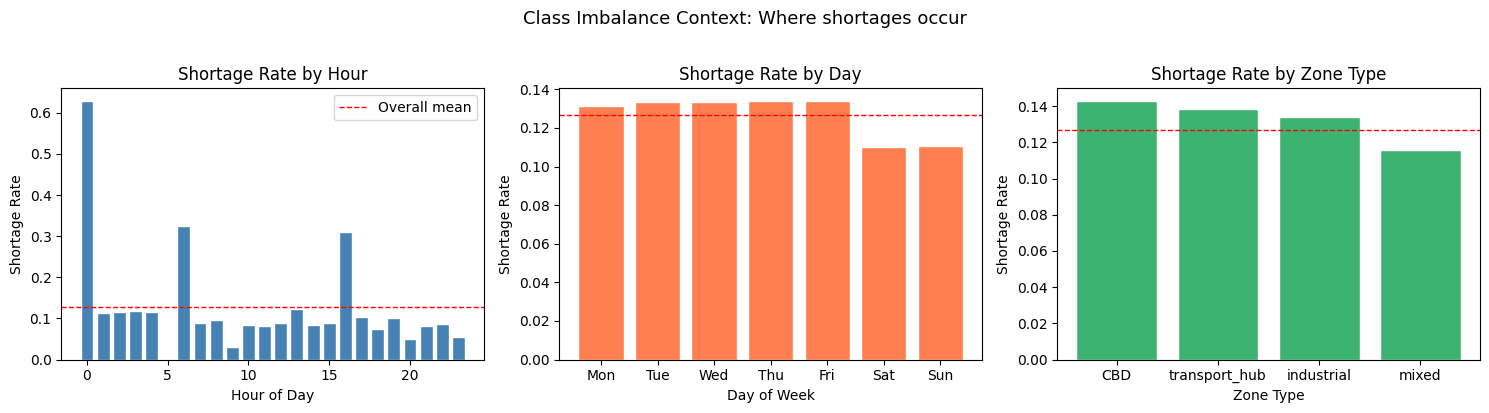

In [5]:
# ── Shortage distribution by hour and zone type ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# By hour
hour_rate = df.groupby('hour_of_day')['supply_shortage'].mean()
axes[0].bar(hour_rate.index, hour_rate.values, color='steelblue', edgecolor='white')
axes[0].set_title('Shortage Rate by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Shortage Rate')
axes[0].axhline(df['supply_shortage'].mean(), color='red', linestyle='--', linewidth=1, label='Overall mean')
axes[0].legend()

# By day of week
dow_rate = df.groupby('day_of_week')['supply_shortage'].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(dow_labels, dow_rate.values, color='coral', edgecolor='white')
axes[1].set_title('Shortage Rate by Day')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Shortage Rate')
axes[1].axhline(df['supply_shortage'].mean(), color='red', linestyle='--', linewidth=1)

# By zone type
zone_rate = df.groupby('zone_type')['supply_shortage'].mean().sort_values(ascending=False)
axes[2].bar(zone_rate.index, zone_rate.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Shortage Rate by Zone Type')
axes[2].set_xlabel('Zone Type')
axes[2].set_ylabel('Shortage Rate')
axes[2].axhline(df['supply_shortage'].mean(), color='red', linestyle='--', linewidth=1)

plt.suptitle('Class Imbalance Context: Where shortages occur', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# =========================================================
# 3b. FEATURE ENGINEERING (same as Exp 2)
# =========================================================
Reproducing the Exp 2 feature set. All lags use shift(N ≥ 1).

In [6]:
grp = df.groupby('zone_id')['taxi_count']

# Lags
for n, col in [(1,'taxi_lag_1h'),(2,'taxi_lag_2h'),(3,'taxi_lag_3h'),
               (24,'taxi_lag_24h'),(48,'taxi_lag_48h'),(168,'taxi_lag_168h')]:
    df[col] = grp.shift(n)
    df[col] = df[col].fillna(df.groupby('zone_id')[col].transform('mean'))

# Rolling means (shift(1) inside prevents leakage)
for w, col in [(3,'taxi_rolling_3h_mean'),(6,'taxi_rolling_6h_mean'),
               (12,'taxi_rolling_12h_mean'),(24,'taxi_rolling_24h_mean')]:
    rolled     = grp.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    zone_means = grp.transform('mean')
    df[col]    = rolled.fillna(zone_means)

# Rolling std
for w, col in [(3,'taxi_rolling_3h_std'),(6,'taxi_rolling_6h_std')]:
    df[col] = grp.transform(lambda s: s.shift(1).rolling(w, min_periods=2).std()).fillna(0).clip(0)

df['taxi_rolling_3h_max']   = grp.transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
df['taxi_rolling_3h_min']   = grp.transform(lambda s: s.shift(1).rolling(3, min_periods=1).min())
df['taxi_rolling_3h_range'] = df['taxi_rolling_3h_max'] - df['taxi_rolling_3h_min']

# Depletion & trend
df['depletion_rate_1h']  = ((df['taxi_lag_1h'] - df['taxi_count']) / (df['taxi_lag_1h'] + 1)).clip(-2,2)
df['depletion_rate_3h']  = ((df['taxi_rolling_3h_mean'] - df['taxi_count']) / (df['taxi_rolling_3h_mean'] + 1)).clip(-2,2)
df['depletion_rate_6h']  = ((df['taxi_rolling_6h_mean'] - df['taxi_count']) / (df['taxi_rolling_6h_mean'] + 1)).clip(-2,2)
df['supply_vs_yesterday']= (df['taxi_count'] / (df['taxi_lag_24h'] + 1)).clip(0, 5)
df['supply_trend_3v6']   = df['taxi_rolling_3h_mean'] - df['taxi_rolling_6h_mean']
df['supply_trend_6v12']  = df['taxi_rolling_6h_mean'] - df['taxi_rolling_12h_mean']

# Cyclical
df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['hours_to_peak'] = df['hour_of_day'].map(lambda h: min((p-h)%24 for p in [7,17]))

# Weather interactions
df['rain_x_peak']      = df['is_raining'].astype(int) * df['is_peak_hour'].astype(int)
df['rain_x_depletion'] = df['rainfall_mm'] * df['depletion_rate_1h'].clip(0, None)
df['rainfall_sqrt']    = np.sqrt(df['rainfall_mm'])
df['rain_intensity']   = pd.cut(df['rainfall_mm'],
    bins=[-0.1, 0.0, 2.0, 10.0, float('inf')], labels=[0,1,2,3]).astype(int)

# Zone type encoding
ZONE_TYPE_ENC = {'CBD':0,'transport_hub':1,'residential':2,'mixed':3,'industrial':4}
df['zone_type_encoded'] = df['zone_type'].map(ZONE_TYPE_ENC).fillna(3).astype(int)

print('Feature engineering complete.')
print(f'DataFrame shape: {df.shape}')

Feature engineering complete.


DataFrame shape: (118800, 55)


# =========================================================
# 4. RESAMPLING TECHNIQUES — Overview
# =========================================================

In [7]:
# Summary of strategies to be tested
strategies = [
    ('none',       'No resampling',       'LightGBM default — imbalance handled implicitly'),
    ('weighted',   'class_weight',        'Scale loss to penalise majority class misses'),
    ('smote',      'SMOTE',               'Interpolate new minority examples in feature space'),
    ('oversample', 'RandomOverSampler',   'Randomly duplicate minority rows'),
    ('undersample','RandomUnderSampler',  'Randomly drop majority rows (loses data)'),
    ('smotetomek', 'SMOTETomek',          'SMOTE + remove borderline Tomek link pairs'),
]

print(f'{"ID":<12}  {"Strategy":<22}  Description')
print('-' * 75)
for sid, name, desc in strategies:
    print(f'{sid:<12}  {name:<22}  {desc}')

ID            Strategy                Description
---------------------------------------------------------------------------
none          No resampling           LightGBM default — imbalance handled implicitly
weighted      class_weight            Scale loss to penalise majority class misses
smote         SMOTE                   Interpolate new minority examples in feature space
oversample    RandomOverSampler       Randomly duplicate minority rows
undersample   RandomUnderSampler      Randomly drop majority rows (loses data)
smotetomek    SMOTETomek              SMOTE + remove borderline Tomek link pairs


# =========================================================
# 5. FEATURE SELECTION (Exp 2 final feature set)
# =========================================================

In [8]:
# Use the 17-feature set from Exp 2 that survived MI + RF selection
FINAL_FEATURES = [
    'hour_of_day', 'hour_cos', 'is_raining', 'rainfall_sqrt', 'hours_to_peak',
    'rainfall_mm', 'depletion_rate_3h', 'rain_intensity', 'depletion_rate_6h',
    'hour_sin', 'taxi_count', 'rain_x_depletion', 'depletion_rate_1h',
    'supply_vs_yesterday', 'carpark_available_lots', 'congestion_ratio', 'taxi_lag_24h',
]

missing = [c for c in FINAL_FEATURES if c not in df.columns]
print(f'Feature set: {len(FINAL_FEATURES)} features')
print(f'Missing: {missing if missing else "None ✓"}')

Feature set: 17 features
Missing: None ✓


# =========================================================
# 6. TRAIN / TEST SPLIT
# =========================================================
Temporal split — shuffle=False preserves time ordering and prevents future leakage.

In [9]:
KEEP_FOR_NORM = ['zone_id', 'hour_of_day', 'is_weekend', 'taxi_count']
all_cols = list(dict.fromkeys(FINAL_FEATURES + ['supply_shortage', 'zone_name', 'region'] + KEEP_FOR_NORM))
split_df = df[[c for c in all_cols if c in df.columns]].copy()

for col in split_df.select_dtypes(include='bool').columns:
    split_df[col] = split_df[col].astype(int)

X = split_df.drop(columns=['supply_shortage'])
y = split_df['supply_shortage']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw  = X_test_raw.reset_index(drop=True)
y_train     = y_train.reset_index(drop=True)
y_test      = y_test.reset_index(drop=True)

print(f'Train: {len(X_train_raw):,} rows  shortage={y_train.mean():.2%}')
print(f'Test:  {len(X_test_raw):,}  rows  shortage={y_test.mean():.2%}')

Train: 95,040 rows  shortage=12.70%
Test:  23,760  rows  shortage=12.56%


# =========================================================
# 7. ENCODE, ZONE-NORMALISE & SCALE
# =========================================================
All transforms fit on train only — no test data visible during fitting.

In [10]:
# ── Zone normalisation (fit on train only) ────────────────────────────────────
zone_baseline = (
    X_train_raw.groupby(['zone_id','hour_of_day','is_weekend'])['taxi_count']
    .mean().reset_index(name='zone_hour_baseline')
)
global_mean = X_train_raw['taxi_count'].mean()

for part in [X_train_raw, X_test_raw]:
    merged = part.merge(zone_baseline, on=['zone_id','hour_of_day','is_weekend'], how='left')
    merged['zone_hour_baseline'] = merged['zone_hour_baseline'].fillna(global_mean)
    part['supply_vs_zone_baseline'] = (
        merged['taxi_count'] / (merged['zone_hour_baseline'] + 1)
    ).clip(0, 5).values

if 'supply_vs_zone_baseline' not in FINAL_FEATURES:
    FINAL_FEATURES.append('supply_vs_zone_baseline')

# ── Drop helper cols, OHE, impute ─────────────────────────────────────────────
drop_raw = ['zone_id', 'zone_name', 'region']
X_train = X_train_raw[[c for c in FINAL_FEATURES if c in X_train_raw.columns]].copy()
X_test  = X_test_raw [[c for c in FINAL_FEATURES if c in X_test_raw.columns ]].copy()

for col in X_train.select_dtypes(include=[float,int]).columns:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)

# ── Scale ────────────────────────────────────────────────────────────────────
scale_cols = [c for c in [
    'taxi_count','taxi_lag_24h','rainfall_mm','rainfall_sqrt',
    'depletion_rate_1h','depletion_rate_3h','depletion_rate_6h',
    'supply_vs_yesterday','supply_vs_zone_baseline',
    'rain_x_depletion','carpark_available_lots','congestion_ratio','hours_to_peak',
] if c in X_train.columns]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test [scale_cols] = scaler.transform    (X_test [scale_cols])

print(f'Train shape: {X_train.shape}  |  Test shape: {X_test.shape}')
print(f'Features: {list(X_train.columns)}')

Train shape: (95040, 18)  |  Test shape: (23760, 18)
Features: ['hour_of_day', 'hour_cos', 'is_raining', 'rainfall_sqrt', 'hours_to_peak', 'rainfall_mm', 'depletion_rate_3h', 'rain_intensity', 'depletion_rate_6h', 'hour_sin', 'taxi_count', 'rain_x_depletion', 'depletion_rate_1h', 'supply_vs_yesterday', 'carpark_available_lots', 'congestion_ratio', 'taxi_lag_24h', 'supply_vs_zone_baseline']


# =========================================================
# 8. BUILD MODELS — One per Strategy
# =========================================================

In [11]:
def make_lgbm(scale_pos_weight=None):
    """Return a fresh LGBMClassifier. Use scale_pos_weight for weighted variant."""
    params = dict(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    )
    if scale_pos_weight is not None:
        params['scale_pos_weight'] = scale_pos_weight   # equiv. to class_weight
    return lgb.LGBMClassifier(**params)

# Compute imbalance ratio for scale_pos_weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (majority/minority): {pos_weight:.2f}')

scale_pos_weight (majority/minority): 6.88


In [12]:
# ── Strategy 1: No resampling ─────────────────────────────────────────────────
print('Training: No resampling...')
m_none = make_lgbm()
m_none.fit(X_train, y_train,
           eval_set=[(X_test, y_test)],
           callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)])
print('  done.')

# ── Strategy 2: class_weight (scale_pos_weight) ───────────────────────────────
print('Training: class_weight (scale_pos_weight)...')
m_weighted = make_lgbm(scale_pos_weight=pos_weight)
m_weighted.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)])
print('  done.')

Training: No resampling...


  done.
Training: class_weight (scale_pos_weight)...


  done.


In [13]:
# ── Strategy 3: SMOTE ────────────────────────────────────────────────────────
print('Resampling with SMOTE...')
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f'  After SMOTE: {len(X_smote):,} rows  shortage={y_smote.mean():.2%}')

m_smote = make_lgbm()
m_smote.fit(X_smote, y_smote,
            eval_set=[(X_test, y_test)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)])
print('  done.')

# ── Strategy 4: RandomOverSampler ────────────────────────────────────────────
print('Resampling with RandomOverSampler...')
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
print(f'  After ROS:   {len(X_ros):,} rows  shortage={y_ros.mean():.2%}')

m_ros = make_lgbm()
m_ros.fit(X_ros, y_ros,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)])
print('  done.')

Resampling with SMOTE...
  After SMOTE: 165,944 rows  shortage=50.00%


  done.
Resampling with RandomOverSampler...
  After ROS:   165,944 rows  shortage=50.00%


  done.


In [14]:
# ── Strategy 5: RandomUnderSampler ───────────────────────────────────────────
print('Resampling with RandomUnderSampler...')
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print(f'  After RUS:   {len(X_rus):,} rows  shortage={y_rus.mean():.2%}')

m_rus = make_lgbm()
m_rus.fit(X_rus, y_rus,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)])
print('  done.')

# ── Strategy 6: SMOTETomek ────────────────────────────────────────────────────
print('Resampling with SMOTETomek...')
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_train, y_train)
print(f'  After SMOTETomek: {len(X_smt):,} rows  shortage={y_smt.mean():.2%}')

m_smt = make_lgbm()
m_smt.fit(X_smt, y_smt,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)])
print('  done.')

Resampling with RandomUnderSampler...
  After RUS:   24,136 rows  shortage=50.00%


  done.
Resampling with SMOTETomek...


  After SMOTETomek: 165,116 rows  shortage=50.00%


  done.


# =========================================================
# 9. EVALUATE & COMPARE ALL STRATEGIES
# =========================================================

In [15]:
def eval_model(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    return {
        'strategy':  name,
        'auc':       round(roc_auc_score(y_t, y_prob), 4),
        'pr_auc':    round(average_precision_score(y_t, y_prob), 4),
        'f1':        round(f1_score(y_t, y_pred), 4),
        'precision': round(precision_score(y_t, y_pred), 4),
        'recall':    round(recall_score(y_t, y_pred), 4),
        '_model':    model,
        '_prob':     y_prob,
        '_pred':     y_pred,
    }

results = [
    eval_model('None (baseline)',      m_none,     X_test, y_test),
    eval_model('class_weight',         m_weighted, X_test, y_test),
    eval_model('SMOTE',                m_smote,    X_test, y_test),
    eval_model('RandomOverSampler',    m_ros,      X_test, y_test),
    eval_model('RandomUnderSampler',   m_rus,      X_test, y_test),
    eval_model('SMOTETomek',           m_smt,      X_test, y_test),
]

results_df = pd.DataFrame(results).drop(columns=['_model','_prob','_pred'])
results_df = results_df.sort_values('f1', ascending=False).reset_index(drop=True)

print('=== Strategy Comparison (sorted by F1) ===')
print(results_df.to_string(index=False))

=== Strategy Comparison (sorted by F1) ===
          strategy    auc  pr_auc     f1  precision  recall
RandomUnderSampler 0.8084  0.4388 0.4046     0.3234  0.5404
 RandomOverSampler 0.8051  0.4311 0.3887     0.3189  0.4975
             SMOTE 0.7987  0.4217 0.3758     0.3337  0.4302
        SMOTETomek 0.7986  0.4227 0.3758     0.3335  0.4305
   None (baseline) 0.8178  0.4499 0.3165     0.7309  0.2020
      class_weight 0.7992  0.4139 0.1766     0.8522  0.0985


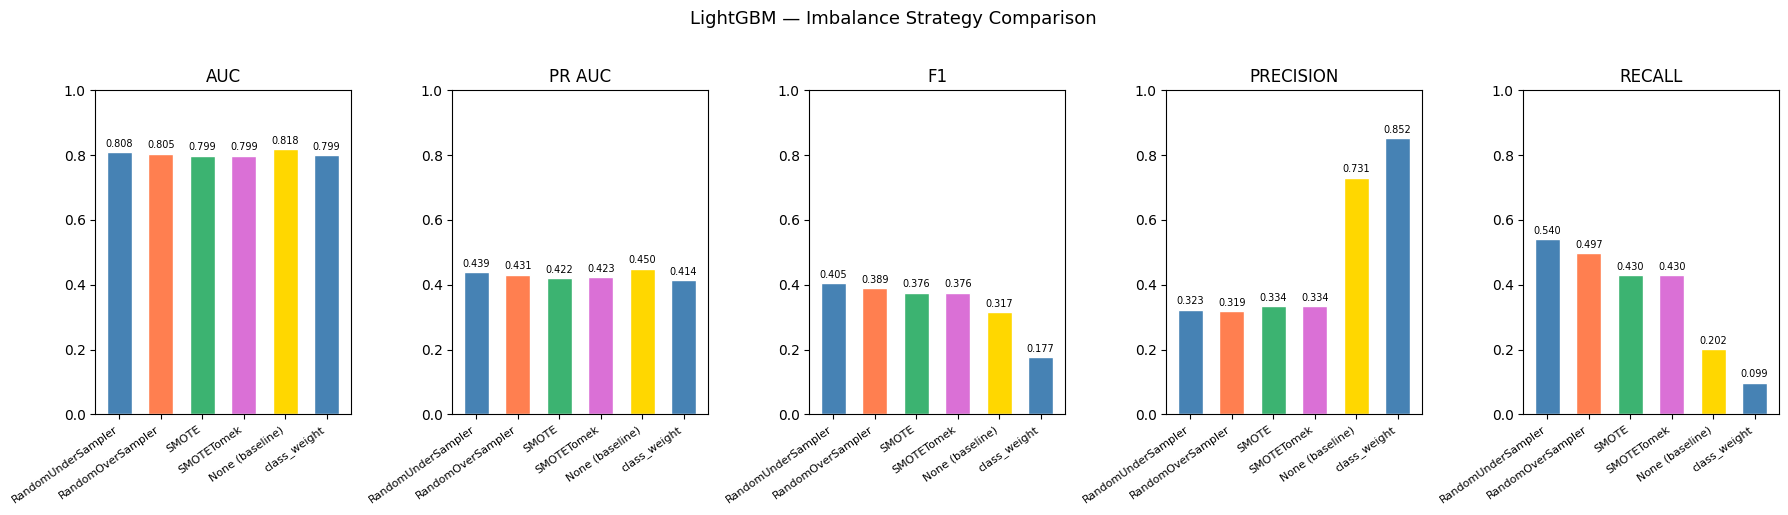

In [16]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_plot = ['auc', 'pr_auc', 'f1', 'precision', 'recall']
plot_df = results_df.set_index('strategy')[metrics_plot]

fig, axes = plt.subplots(1, len(metrics_plot), figsize=(18, 5), sharey=False)
colors = ['steelblue','coral','mediumseagreen','orchid','gold']

for i, (metric, ax) in enumerate(zip(metrics_plot, axes)):
    bars = ax.bar(range(len(plot_df)), plot_df[metric].values,
                  color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(metric.upper().replace('_',' '))
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, plot_df[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('LightGBM — Imbalance Strategy Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

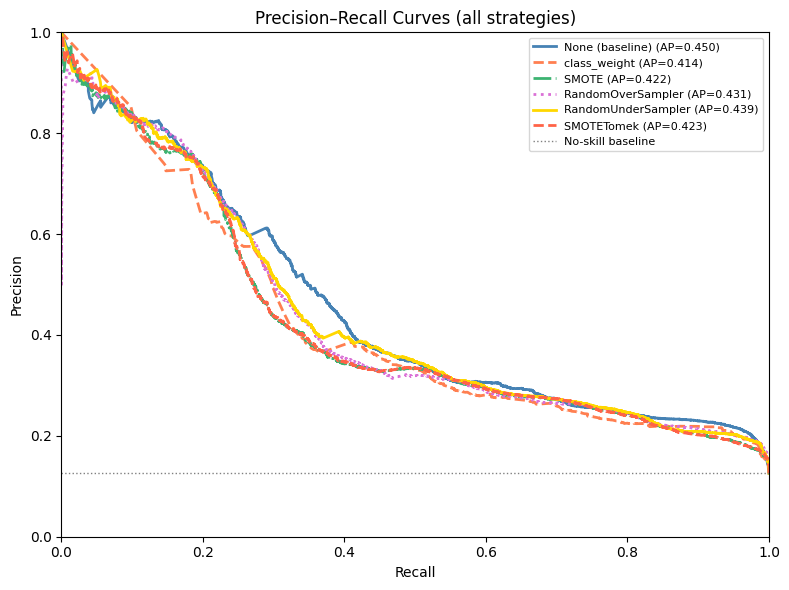

In [17]:
# ── Precision–Recall curves for all strategies ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

line_styles = ['-','--','-.',':','-','--']
strat_colors = ['steelblue','coral','mediumseagreen','orchid','gold','tomato']

for r, ls, col in zip(results, line_styles, strat_colors):
    prec, rec, _ = precision_recall_curve(y_test, r['_prob'])
    ap = r['pr_auc']
    ax.plot(rec, prec, ls=ls, color=col, linewidth=2,
            label=f"{r['strategy']} (AP={ap:.3f})")

ax.axhline(y_test.mean(), color='grey', linestyle=':', linewidth=1, label='No-skill baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curves (all strategies)')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

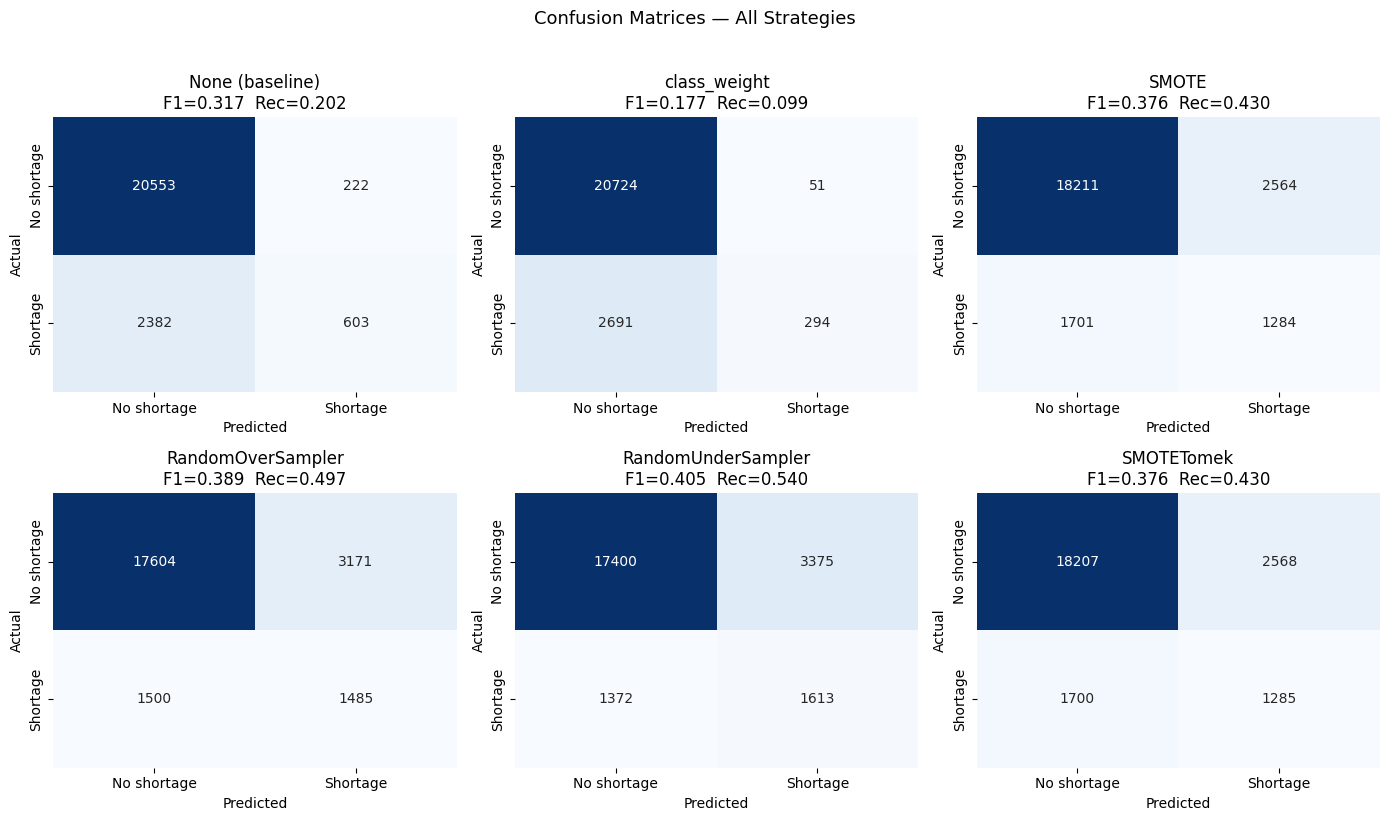

In [18]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, r in enumerate(results):
    cm = confusion_matrix(y_test, r['_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False,
                xticklabels=['No shortage','Shortage'],
                yticklabels=['No shortage','Shortage'])
    axes[i].set_title(f"{r['strategy']}\nF1={r['f1']:.3f}  Rec={r['recall']:.3f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Strategies', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ── Pick best strategy ────────────────────────────────────────────────────────
best = results_df.iloc[0]
print(f'Best strategy by F1: {best["strategy"]}')
print(f'  AUC-ROC    : {best["auc"]:.4f}')
print(f'  PR-AUC     : {best["pr_auc"]:.4f}')
print(f'  F1         : {best["f1"]:.4f}')
print(f'  Precision  : {best["precision"]:.4f}')
print(f'  Recall     : {best["recall"]:.4f}')
print()

# Full classification report for best model
best_result = next(r for r in results if r['strategy'] == best['strategy'])
best_model  = best_result['_model']
print(classification_report(y_test, best_result['_pred'],
                             target_names=['No shortage', 'Shortage']))

Best strategy by F1: RandomUnderSampler
  AUC-ROC    : 0.8084
  PR-AUC     : 0.4388
  F1         : 0.4046
  Precision  : 0.3234
  Recall     : 0.5404

              precision    recall  f1-score   support

 No shortage       0.93      0.84      0.88     20775
    Shortage       0.32      0.54      0.40      2985

    accuracy                           0.80     23760
   macro avg       0.63      0.69      0.64     23760
weighted avg       0.85      0.80      0.82     23760



# =========================================================
# 10. THRESHOLD TUNING ON BEST STRATEGY
# =========================================================
Default threshold is 0.5. Lowering it increases recall at the cost of precision.
For ops use: catching a shortage (high recall) > false alarm rate.

In [20]:
best_prob = best_result['_prob']
thresholds = np.arange(0.10, 0.71, 0.05)
thresh_rows = []

for t in thresholds:
    y_pred_t = (best_prob >= t).astype(int)
    thresh_rows.append({
        'threshold': round(t, 2),
        'f1':        round(f1_score(y_test, y_pred_t), 4),
        'precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred_t), 4),
        'predicted_positives': int(y_pred_t.sum()),
    })

thresh_df = pd.DataFrame(thresh_rows)
print(thresh_df.to_string(index=False))

# Best threshold by F1
best_t_row = thresh_df.loc[thresh_df['f1'].idxmax()]
print(f'\nBest threshold by F1: {best_t_row["threshold"]}  '
      f'(F1={best_t_row["f1"]:.4f}, '
      f'Rec={best_t_row["recall"]:.4f}, '
      f'Prec={best_t_row["precision"]:.4f})')

 threshold     f1  precision  recall  predicted_positives
    0.1000 0.3405     0.2120  0.8653                12186
    0.1500 0.3627     0.2320  0.8305                10686
    0.2000 0.3809     0.2515  0.7846                 9313
    0.2500 0.3926     0.2717  0.7072                 7769
    0.3000 0.3916     0.2813  0.6439                 6832
    0.3500 0.3939     0.2899  0.6144                 6327
    0.4000 0.3999     0.3027  0.5889                 5807
    0.4500 0.3987     0.3095  0.5601                 5402
    0.5000 0.4046     0.3234  0.5404                 4988
    0.5500 0.4103     0.3424  0.5119                 4463
    0.6000 0.4068     0.3563  0.4740                 3971
    0.6500 0.4056     0.3809  0.4338                 3400
    0.7000 0.3807     0.4037  0.3601                 2663

Best threshold by F1: 0.55  (F1=0.4103, Rec=0.5119, Prec=0.3424)


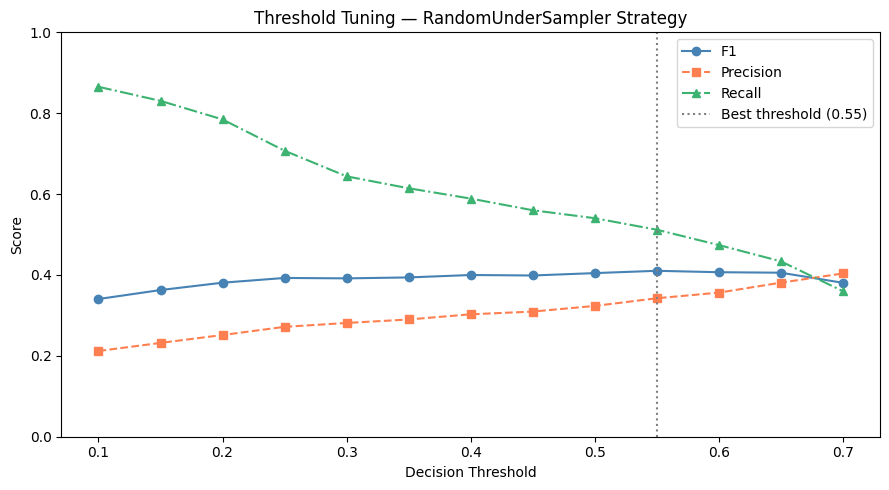

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df['threshold'], thresh_df['f1'],        '-o', label='F1',        color='steelblue')
ax.plot(thresh_df['threshold'], thresh_df['precision'], '--s', label='Precision', color='coral')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    '-.^', label='Recall',   color='mediumseagreen')
ax.axvline(best_t_row['threshold'], color='grey', linestyle=':', linewidth=1.5, label=f'Best threshold ({best_t_row["threshold"]})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Tuning — {best["strategy"]} Strategy')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# =========================================================
# 11. SHAP EXPLANATION — Best Strategy
# =========================================================

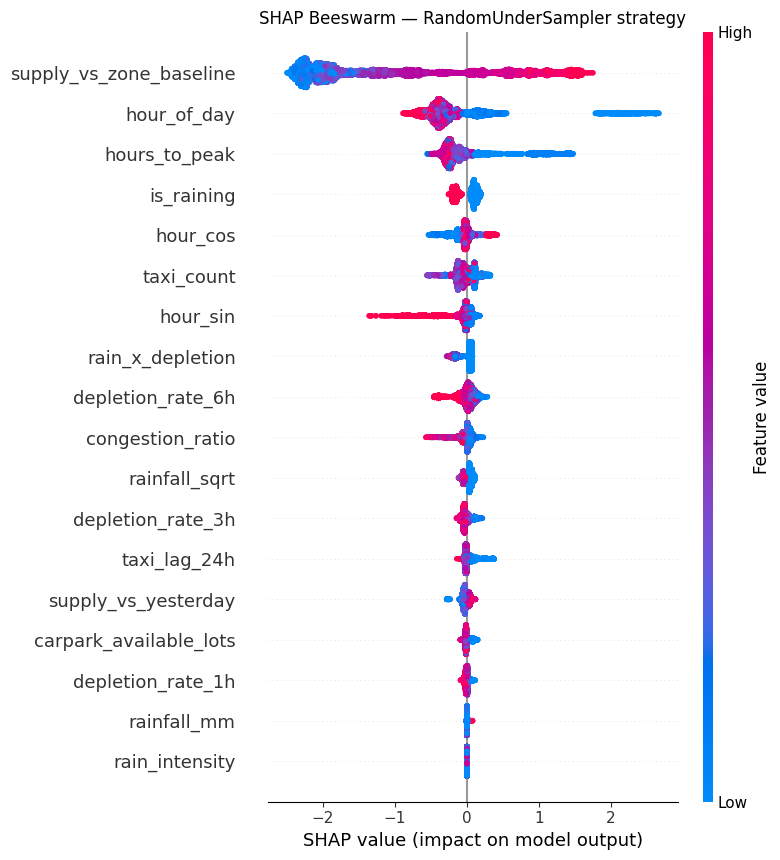

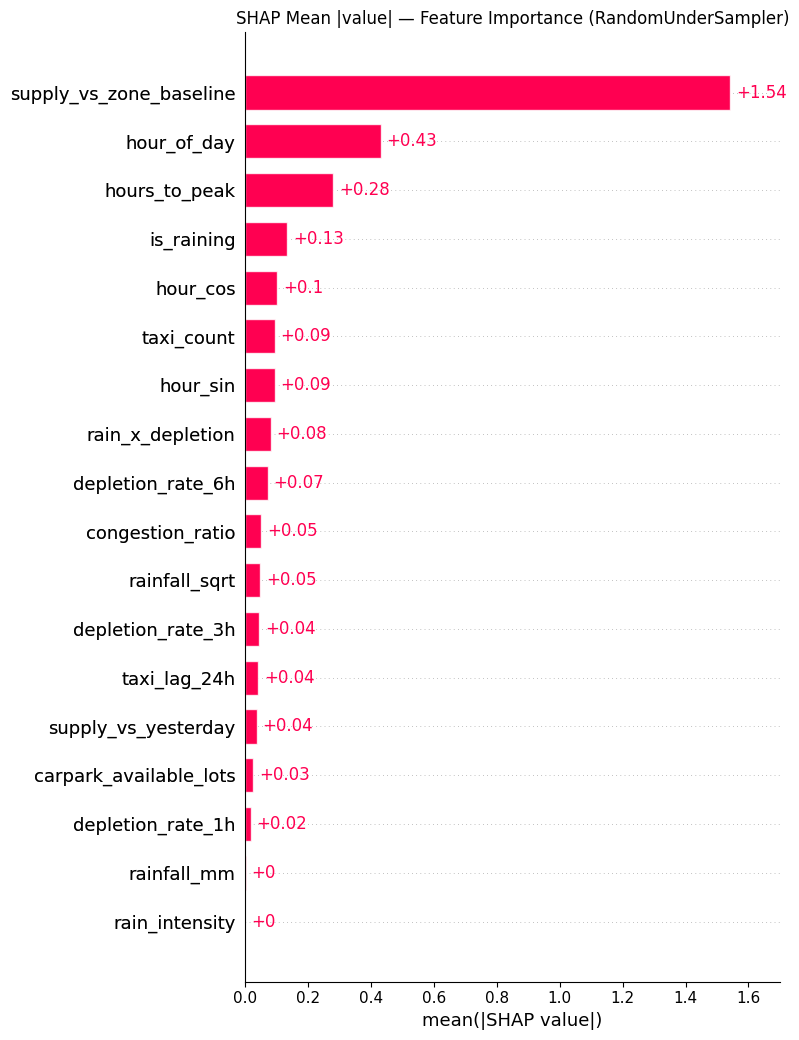

In [22]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

# LightGBM binary: SHAP output may be 2D (n_samples, n_features) or
# 3D (n_samples, n_features, n_classes) — handle both
if shap_values.values.ndim == 3:
    sv = shap_values[..., 1]   # class 1 (shortage)
else:
    sv = shap_values           # already class-1 for binary LightGBM

shap.plots.beeswarm(sv, max_display=18, show=False)
plt.title(f'SHAP Beeswarm — {best["strategy"]} strategy')
plt.tight_layout()
plt.show()

shap.plots.bar(sv, max_display=18, show=False)
plt.title(f'SHAP Mean |value| — Feature Importance ({best["strategy"]})')
plt.tight_layout()
plt.show()

In [23]:
print('=' * 65)
print('EXP 3 SUMMARY')
print('=' * 65)
print()
print('Prior baselines (Decision Tree):')
for name, m in PRIOR.items():
    print(f'  {name:<22}  AUC={m["auc"]:.4f}  F1={m["f1"]:.4f}  Rec={m["recall"]:.4f}')
print()
print('Exp 3 — LightGBM + imbalance strategies:')
for _, row in results_df.iterrows():
    marker = ' ← BEST' if row['strategy'] == best['strategy'] else ''
    print(f'  {row["strategy"]:<24}  AUC={row["auc"]:.4f}  F1={row["f1"]:.4f}  '
          f'Prec={row["precision"]:.4f}  Rec={row["recall"]:.4f}{marker}')
print()
print(f'Best strategy : {best["strategy"]}')
print(f'Best threshold: {best_t_row["threshold"]} '
      f'(F1={best_t_row["f1"]:.4f}, '
      f'Recall={best_t_row["recall"]:.4f}, '
      f'Precision={best_t_row["precision"]:.4f})')
print()
print('Next: Exp 4 — hyperparameter tuning on best strategy')

EXP 3 SUMMARY

Prior baselines (Decision Tree):
  Exp1 DT (9 feat)        AUC=0.8274  F1=0.4128  Rec=0.3576
  Exp2 DT (17 feat)       AUC=0.7669  F1=0.3551  Rec=0.4556

Exp 3 — LightGBM + imbalance strategies:
  RandomUnderSampler        AUC=0.8084  F1=0.4046  Prec=0.3234  Rec=0.5404 ← BEST
  RandomOverSampler         AUC=0.8051  F1=0.3887  Prec=0.3189  Rec=0.4975
  SMOTE                     AUC=0.7987  F1=0.3758  Prec=0.3337  Rec=0.4302
  SMOTETomek                AUC=0.7986  F1=0.3758  Prec=0.3335  Rec=0.4305
  None (baseline)           AUC=0.8178  F1=0.3165  Prec=0.7309  Rec=0.2020
  class_weight              AUC=0.7992  F1=0.1766  Prec=0.8522  Rec=0.0985

Best strategy : RandomUnderSampler
Best threshold: 0.55 (F1=0.4103, Recall=0.5119, Precision=0.3424)

Next: Exp 4 — hyperparameter tuning on best strategy
